In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from siriuspy.clientarch import Time, PVDataSet

from mathphys.functions import load, save

GMTM3 = - 3.0 * 3600.0

In [38]:
pvs = ['SI-Glob:DI-Tune-H:TuneFrac-Mon', 'SI-Glob:DI-Tune-V:TuneFrac-Mon']

pvdata = PVDataSet(pvs)

# pvdata.time_start = Time(2026, 7, 17, 6, 0)
# pvdata.time_stop = Time(2026, 7, 17, 8, 20)

h = 14
pvdata.time_start = Time(2026, 7, 17, h, 0)
pvdata.time_stop = Time(2026, 7, 17, h+1, 0)

pvdata.query_timeout = 20.0
pvdata.update()

1045 104.5


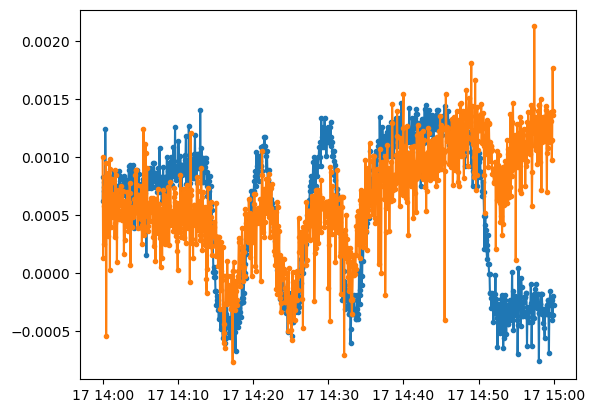

In [40]:
t = (pvdata[pvs[0]].timestamp + GMTM3).astype('datetime64[s]')
v = pvdata[pvs[0]].value
xfar = np.linspace(0, 8, len(t))
yfar = np.sin(2*np.pi*0.09*xfar - np.pi/3)*0.0001
xfinal = v-np.mean(v)+yfar+0.0005

ty = (pvdata[pvs[1]].timestamp + GMTM3).astype('datetime64[s]')
vy = pvdata[pvs[1]].value
xfar = np.linspace(0, 8, len(ty))
yfar = -np.sin(2*np.pi*0.07*xfar)*0.0005
yfinal = vy-np.mean(vy)+yfar+0.0005+0.0001*xfar

step = 25
plt.plot(t[::step], xfinal[::step], '.-')
plt.plot(ty[::step], yfinal[::step], '.-')

tosavey = yfinal[::step]
tosavex = xfinal[::step]
leng = min(len(tosavex), len(tosavey))
tosavex = tosavex[:leng]
tosavey = tosavey[:leng]
print(leng, leng * 0.1)

In [14]:
fpath = '/home/vitor/repos/dev-packages/siriuspy/siriuspy/opticscorr/'
# np.save(fpath+'tunex_noise.npy', tosavex)
# np.save(fpath+'tuney_noise.npy', tosavey)

In [8]:
import numpy as np

import pyaccel as pa
from pymodels import si

from apsuite.optics_analysis.tune_correction import TuneCorr
from siriuspy.opticscorr.csdev import Const

_quadrupole = pa.elements.quadrupole


class A:
    """."""
    def __init__(self):
        """."""
        self._corr_method = Const.CorrMeth.Proportional
        self._corr_group = Const.CorrGroup.TwoKnobs
        self._psfams = Const.SI_QFAMS_TUNECORR
        self._ref_tunex = 0.16
        self._ref_tuney = 0.22

        # SIMULATION ##########################################################
        _model = si.create_accelerator()
        self.SIMQUAD_LENG = 0.1

        _mia = pa.lattice.find_indices(_model, 'fam_name', 'mia')[-1]
        _mib = pa.lattice.find_indices(_model, 'fam_name', 'mib')[2]

        self._sim_quad_indices = [_mib, _mia]

        for i, idx in enumerate(self._sim_quad_indices):
            _model.insert(idx+i,
                _quadrupole(f'SimID_{i}', self.SIMQUAD_LENG, 0.0))
            self._sim_quad_indices[i] = idx + i

        self._sim_tunecorr = TuneCorr(_model, 'SI')
        self._sim_tunecorr.method = 0 \
            if self._corr_method == Const.CorrMeth.Proportional \
            else 1
        self._sim_tunecorr.grouping = self._corr_group
        self._sim_tunecorr.correct_parameters(
            [49+self._ref_tunex, 14+self._ref_tuney])
        self._psfam_refkl = {
            fam: kl for fam, kl in zip(  # ruff:ignore[zip-without-explicit-strict]
                self._psfams,
                self._sim_tunecorr.get_kl(self._sim_tunecorr.model)
            )
        }

    @property
    def model(self):
        """."""
        return self._sim_tunecorr.model

    def get_tunes(self):
        """."""
        _ed = pa.optics.calc_edwards_teng(self._sim_tunecorr.model)[0]
        return np.array([_ed.mu1[-1]/2/np.pi-49, _ed.mu2[-1]/2/np.pi-14])


a = A()

In [9]:
for _, idx in enumerate(a._sim_quad_indices):
    print(a.model[idx])

fam_name   : SimID_0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.1 m
nr_steps   : 10 
fam_name   : SimID_1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.1 m
nr_steps   : 10 


In [10]:
toprint, donothing = False, lambda:None
mat = np.zeros((2, len(a._sim_quad_indices)))
for i, idx in enumerate(a._sim_quad_indices):
    dkl = 0.02
    a.model[idx].KL = -dkl/2
    tneg = a.get_tunes()
    print(tneg) if toprint else donothing()
    a.model[idx].KL = +dkl/2
    tpos = a.get_tunes()
    print(tpos) if toprint else donothing()
    a.model[idx].KL = 0
    print(tpos - tneg, '\n') if toprint else donothing()
    mat[:, i] = (tpos - tneg) / dkl
mat

array([[ 0.12363324,  1.37332562],
       [-0.11120689, -0.2802959 ]])

In [30]:
%timeit pa.tracking.find_m44(a.model)

36.5 ms ± 692 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [28]:
%timeit a.get_tunes()

95.5 ms ± 886 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
imat = np.linalg.inv(mat)
imat

array([[ -2.37399312, -11.63151347],
       [  0.94187747,   1.04712362]])

In [12]:
dtune = np.vstack((tosavex, tosavey))
dkl = imat @ dtune
dkl.shape

(2, 26103)

In [13]:
b = dkl.T.tolist()

In [15]:
np.save(fpath+'klnoise.npy', b)

In [20]:
data = load('situnefb_pidmode0_.pkl')

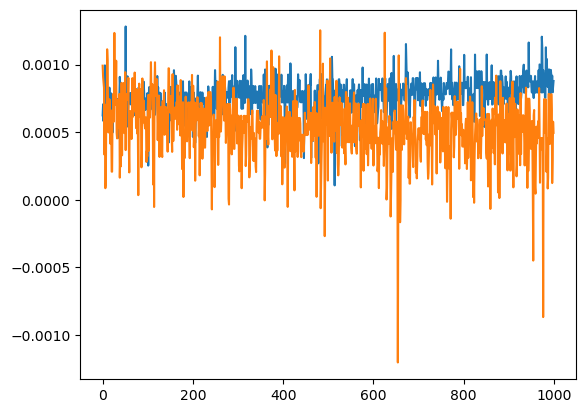

In [36]:
# plt.plot(tosavex[::4][:1000]+0.16)
plt.plot(np.array(data['tunex'][:1000])-0.16)
plt.plot(np.array(data['tuney'][:1000])-0.22)

In [53]:
# fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# DIFF2REF = 0
# # ax01 = ax[0].twinx()
# # ax11 = ax[1].twinx()
# ax1 = ax.twinx()

# r = load('situnefb_purenoise_25cut.pkl')
# tunex = np.array(r['tunex'])[:]
# tuney = np.array(r['tuney'])[:]

# print(f'{tunex.std() = :.3e}, {tuney.std() = :.3e}\n')
# x = np.arange(len(tunex))
# ax.plot(x, tunex, '-', c='C0')
# ax1.plot(x, tuney, '-', c='C1')

# r = load('situnefb_pidmode-1_25cut_nomean.pkl')
# tunex = np.array(r['tunex'])[:]
# tuney = np.array(r['tuney'])[:]
# print(f'{tunex.std() = :.3e}, {tuney.std() = :.3e}\n')
# ax.plot(x + x[-1], tunex, '-', c='C0')
# ax1.plot(x + x[-1], tuney, '-', c='C1')


# ax.yaxis.set_tick_params(labelcolor='C0')
# ax1.yaxis.set_tick_params(labelcolor='C1')

# fig.tight_layout()
# fig.show()

 situnefb_pidmode-1_NC16_usemean-True_pidconfig_0.pkl => Tune X STD = 6.080e-04,  Tune Y STD = 4.355e-04

 situnefb_pidmode-1_NC16_usemean-False_pidconfig_0.pkl => Tune X STD = 6.080e-04,  Tune Y STD = 4.355e-04



/tmp/ipykernel_7800/540308372.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


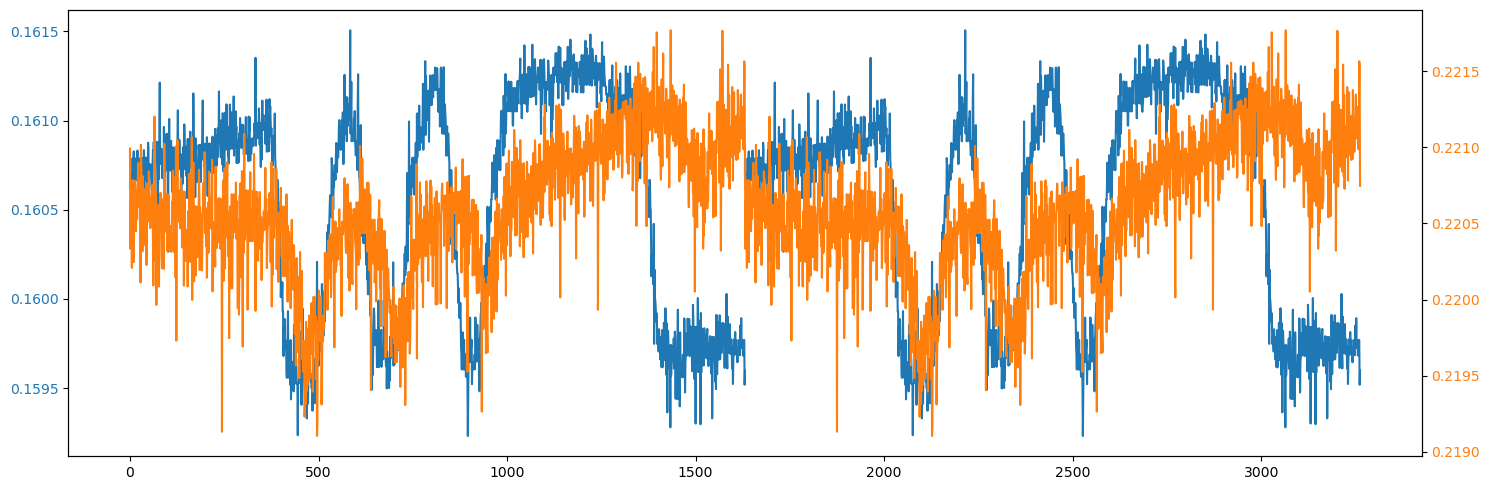

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

DIFF2REF = 0
ax1 = ax.twinx()

fnames = [
    'situnefb_pidmode-1_NC16_usemean-True_pidconfig_0.pkl',
    'situnefb_pidmode-1_NC16_usemean-False_pidconfig_0.pkl',
]
for i, fname in enumerate(fnames):
    r = load(fname)
    tunex = np.array(r['tunex'])[:] - 0.16*DIFF2REF
    tuney = np.array(r['tuney'])[:] - 0.22*DIFF2REF
    strf = f'{" "+fname:.>40s} => '+\
        f'Tune X STD = {tunex.std():.3e},  '+\
        f'Tune Y STD = {tuney.std():.3e}\n'
    print(strf)
    x = np.arange(len(tunex))
    ax.plot(x + x[-1]*i, tunex, '-', c='C0')
    ax1.plot(x + x[-1]*i, tuney, '-', c='C1')

ax.yaxis.set_tick_params(labelcolor='C0')
ax1.yaxis.set_tick_params(labelcolor='C1')

fig.tight_layout()
fig.show()

In [ ]:
plt.annotate

/tmp/ipykernel_7800/3899665258.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


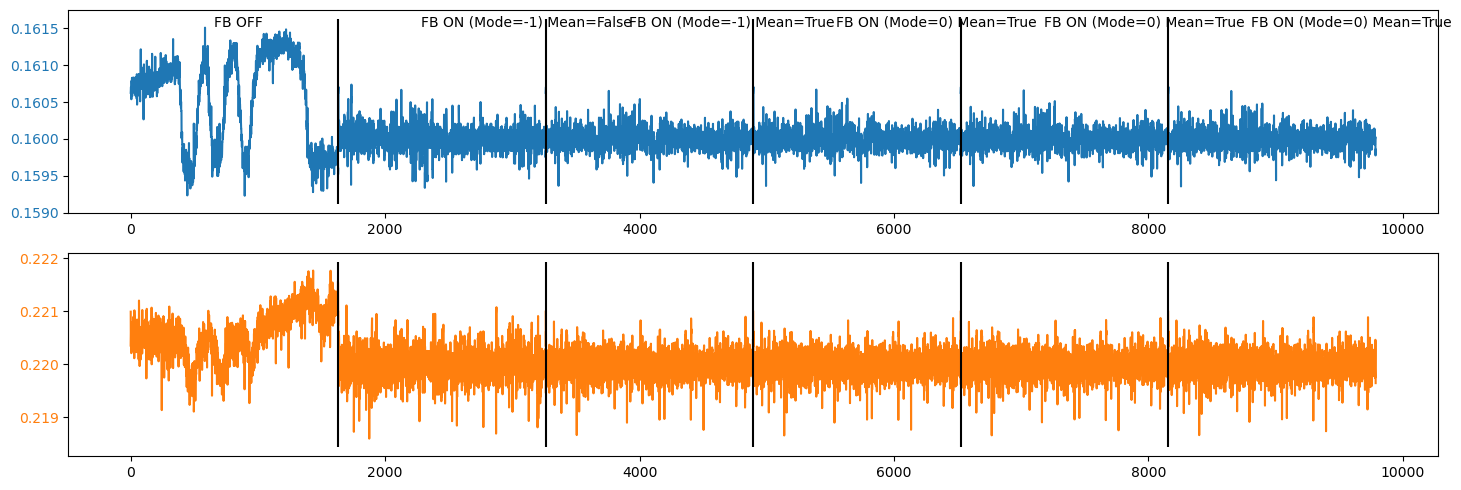

In [142]:
fnames = [
    'situnefb_NC16_purenoise.pkl',
    'situnefb_pidmode-1_NC16_usemean-False_pidconfig_1.pkl',
    'situnefb_pidmode-1_NC16_usemean-True_pidconfig_1.pkl',
    # 'situnefb_pidmode0_NC16_usemean-False_pidconfig_0.pkl',
    # 'situnefb_pidmode0_NC16_usemean-False_pidconfig_1.pkl',
    # 'situnefb_pidmode0_NC16_usemean-False_pidconfig_2.pkl',
    'situnefb_pidmode0_NC16_usemean-True_pidconfig_0.pkl',
    'situnefb_pidmode0_NC16_usemean-True_pidconfig_1.pkl',
    'situnefb_pidmode0_NC16_usemean-True_pidconfig_2.pkl',
]

fig, ax = plt.subplots(2, 1, figsize=(15, 5))

DIFF2REF = 0

subs, hcuts = [], []
for i, fname in enumerate(fnames):
    fnamespl = fname.split('_')[1]
    if fnamespl.startswith('pidmode'):
        subtitle = fnamespl[7:]
        subtitle = 'FB ON (Mode='+subtitle+')'
        subtitle += ' Mean='+(fname.split('usemean-')[1]).split('_')[0]
    else:
        subtitle = 'FB OFF'
    subs.append(subtitle)
    r = load(fname)
    tunex = np.array(r['tunex'])[:] - 0.16*DIFF2REF
    tuney = np.array(r['tuney'])[:] - 0.22*DIFF2REF
    strf = f'{" "+subtitle:.>30s} => '+\
        f'Tune X STD = {tunex.std():.3e},  '+\
        f'Tune Y STD = {tuney.std():.3e}\n'
    # print(strf)
    x = np.arange(len(tunex))
    ax[0].plot(x + x[-1]*i, tunex, '-', c='C0')
    ax[1].plot(x + x[-1]*i, tuney, '-', c='C1')
    if i:
        hcuts.append(x[-1] + x[-1]*(i-1))

ymax = []
for a in ax:
    ylim = a.get_ylim()
    ymax.append(ylim[1])
    a.vlines(hcuts, *ylim, color='k')

for i, sub in enumerate(subs):
    ax[0].annotate(sub, xy=(hcuts[0]*(i+0.4), ymax[0]-0.0001))

ax[0].yaxis.set_tick_params(labelcolor='C0')
ax[1].yaxis.set_tick_params(labelcolor='C1')

fig.tight_layout()
fig.show();